# Fast Audio Encoder Training (30 min max)

**MINIMAL approach for ESP32:**
1. Use 2 samples per question (male + female voice diversity)
2. Train simple CNN on mel-spectrograms (no YAMNet)
3. 100 epochs max

**Output:**
- `audio_encoder.tflite` (~100-300KB)
- `embeddings.bin` (pre-computed text embeddings)
- `intents.txt` (question strings)

In [1]:
# Install dependencies
!uv add tensorflow librosa soundfile sentence-transformers numpy matplotlib tqdm
print("Done!")

Resolved 175 packages in 1ms
Audited 167 packages in 5ms
Done!


In [2]:
from pathlib import Path
import numpy as np
import json
import struct
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Paths
WORK_DIR = Path('/workspace') if Path('/workspace').exists() else Path('.').resolve()
AUDIO_DIR = WORK_DIR / 'audio_data'
MODEL_DIR = WORK_DIR / 'models'
DATA_DIR = WORK_DIR / 'data' / 'raw'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Audio specs (MUST match ESP32 code)
SAMPLE_RATE = 16000
MEL_BINS = 64
MEL_FRAMES = 96
EMBEDDING_DIM = 256

# Training (FAST settings)
BATCH_SIZE = 64
EPOCHS = 100  # Reduced from 5000!
LEARNING_RATE = 1e-3
TEMPERATURE = 0.1

print(f"Work dir: {WORK_DIR}")
print(f"Audio dir: {AUDIO_DIR}")
print(f"Mel-spectrogram: {MEL_BINS}x{MEL_FRAMES} -> {EMBEDDING_DIM}-dim")

Work dir: /workspace
Audio dir: /workspace/audio_data
Mel-spectrogram: 64x96 -> 256-dim


## 1. Load Data (2 samples per question for voice diversity)

In [3]:
# Load metadata and keep 2 samples per bucket (male + female voice diversity)
print("Loading metadata...")

SAMPLES_PER_QUESTION = 2  # For voice diversity (male + female)

all_metadata = []
for mf in sorted(AUDIO_DIR.glob('metadata_worker_*.json')):
    with open(mf) as f:
        all_metadata.extend(json.load(f))

print(f"Total samples: {len(all_metadata)}")

# Group samples by bucket
from collections import defaultdict
bucket_samples = defaultdict(list)
for item in all_metadata:
    if Path(item['file']).exists():
        bucket_samples[item['bucket_id']].append(item)

# Select up to SAMPLES_PER_QUESTION per bucket
# Try to pick diverse samples (different files = different voices)
metadata = []
for bid, samples in bucket_samples.items():
    # Shuffle to get random voice selection
    random.shuffle(samples)
    # Take up to N samples
    for sample in samples[:SAMPLES_PER_QUESTION]:
        metadata.append(sample)

print(f"Reduced to: {len(metadata)} samples ({SAMPLES_PER_QUESTION} per question)")
print(f"Unique questions: {len(bucket_samples)}")
print(f"Reduction: {len(all_metadata)} -> {len(metadata)} ({100*len(metadata)/len(all_metadata):.1f}%)")

Loading metadata...
Total samples: 31504
Reduced to: 3360 samples (2 per question)
Unique questions: 1680
Reduction: 31504 -> 3360 (10.7%)


## 2. Extract Mel-Spectrograms

In [4]:
import librosa
import tensorflow as tf

def extract_mel_spectrogram(audio_path):
    """Extract mel-spectrogram matching ESP32 format: (64, 96)"""
    # Load audio
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
    
    # Pad or trim to ~3 seconds (48000 samples)
    target_len = SAMPLE_RATE * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    
    # Extract mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_mels=MEL_BINS,
        n_fft=1024,
        hop_length=512,
        fmin=125,
        fmax=7500
    )
    
    # Convert to log scale
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Normalize to [0, 1]
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # Pad/trim to exact frame count
    if mel_norm.shape[1] < MEL_FRAMES:
        mel_norm = np.pad(mel_norm, ((0,0), (0, MEL_FRAMES - mel_norm.shape[1])))
    else:
        mel_norm = mel_norm[:, :MEL_FRAMES]
    
    return mel_norm.astype(np.float32)

# Test
test_mel = extract_mel_spectrogram(metadata[0]['file'])
print(f"Mel-spectrogram shape: {test_mel.shape}")
print(f"Value range: [{test_mel.min():.3f}, {test_mel.max():.3f}]")

2025-11-29 17:31:16.506526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Mel-spectrogram shape: (64, 96)
Value range: [0.000, 1.000]


In [5]:
# Extract all mel-spectrograms (FAST - only ~3400 samples with 2 per question)
print(f"Extracting mel-spectrograms for {len(metadata)} samples...")

mel_spectrograms = []
valid_metadata = []

for item in tqdm(metadata):
    try:
        mel = extract_mel_spectrogram(item['file'])
        mel_spectrograms.append(mel)
        valid_metadata.append(item)
    except Exception as e:
        print(f"Error: {item['file']}: {e}")

mel_spectrograms = np.array(mel_spectrograms)
print(f"\nExtracted: {mel_spectrograms.shape}")

Extracting mel-spectrograms for 3360 samples...


100%|██████████| 3360/3360 [01:16<00:00, 44.17it/s]



Extracted: (3360, 64, 96)


## 3. Get Text Embeddings (ONE per unique question, not per sample!)

In [6]:
from sentence_transformers import SentenceTransformer

print("Loading text encoder...")
text_encoder = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Get UNIQUE texts only (one per bucket, not per audio sample!)
all_texts = [item['text'] for item in valid_metadata]
unique_texts = list(dict.fromkeys(all_texts))  # Preserve order, remove duplicates

print(f"Total audio samples: {len(all_texts)}")
print(f"Unique questions: {len(unique_texts)}")

# Create mapping: text -> index
text_to_idx = {text: i for i, text in enumerate(unique_texts)}

# Create labels for each audio sample (index of its text in unique_texts)
sample_labels = np.array([text_to_idx[item['text']] for item in valid_metadata])

print(f"Label range: 0 to {sample_labels.max()}")

# Encode only unique texts
text_embeddings = text_encoder.encode(unique_texts, show_progress_bar=True)
print(f"Text embeddings: {text_embeddings.shape}  (one per unique question)")

Loading text encoder...
Total audio samples: 3360
Unique questions: 1792
Label range: 0 to 1791


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Text embeddings: (1792, 768)  (one per unique question)


## 4. Build Simple Audio Encoder (for ESP32)

In [8]:
# Simple CNN that runs on ESP32
# Input: (64, 96, 1) mel-spectrogram
# Output: 256-dim L2-normalized embedding

audio_encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MEL_BINS, MEL_FRAMES, 1)),
    
    # Conv block 1: 64x96 -> 32x48
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    
    # Conv block 2: 32x48 -> 16x24  
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    
    # Conv block 3: 16x24 -> 8x12
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    
    # Conv block 4: 8x12 -> 4x6
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    
    # Global average pooling -> 128
    tf.keras.layers.GlobalAveragePooling2D(),
    
    # Dense to embedding dim
    tf.keras.layers.Dense(EMBEDDING_DIM),
    
    # L2 normalize
    tf.keras.layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))
], name='audio_encoder')

# Text projection (768 -> 256)
text_projection = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(768,)),
    tf.keras.layers.Dense(EMBEDDING_DIM),
    tf.keras.layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))
], name='text_projection')

print("Audio Encoder (runs on ESP32):")
audio_encoder.summary()
print(f"\nText Projection:")
text_projection.summary()

Audio Encoder (runs on ESP32):
Model: "audio_encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 64, 96, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 32, 48, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 48, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 16, 24, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 16, 24, 128)       73856     
                                                                 
 max_pooling2d_6 (MaxP

## 5. Train with Contrastive Loss

In [9]:
# Prepare data
X_audio = mel_spectrograms[..., np.newaxis]  # Add channel dim
X_labels = sample_labels  # Index into text_embeddings for each audio sample

# Project text embeddings to 256-dim (will be done by text_projection model)
# For now, just store the 768-dim embeddings
X_text_full = text_embeddings  # [num_unique_texts, 768]

print(f"Audio input: {X_audio.shape}")
print(f"Labels: {X_labels.shape} (range: {X_labels.min()}-{X_labels.max()})")
print(f"Unique text embeddings: {X_text_full.shape}")

# Create dataset with (audio, label) pairs
dataset = tf.data.Dataset.from_tensor_slices((X_audio, X_labels))
dataset = dataset.shuffle(len(X_audio)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Batches per epoch: {len(X_audio) // BATCH_SIZE}")

Audio input: (3360, 64, 96, 1)
Labels: (3360,) (range: 0-1791)
Unique text embeddings: (1792, 768)
Batches per epoch: 52


In [10]:
# Project ALL text embeddings once (not per batch)
# This creates the target embedding space
X_text_768 = tf.constant(X_text_full, dtype=tf.float32)

# Contrastive loss with proper labels
# audio_emb: [batch, 256] - audio embeddings
# labels: [batch] - index of correct text for each audio
# all_text_emb: [num_texts, 256] - all projected text embeddings
def contrastive_loss(audio_emb, labels, all_text_emb, temperature=TEMPERATURE):
    # Compute similarity of each audio to ALL texts
    logits = tf.matmul(audio_emb, all_text_emb, transpose_b=True) / temperature  # [batch, num_texts]
    
    # Cross-entropy loss: each audio should match its labeled text
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    return tf.reduce_mean(loss)

optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
all_vars = audio_encoder.trainable_variables + text_projection.trainable_variables

@tf.function
def train_step(audio_batch, label_batch, all_text_768):
    with tf.GradientTape() as tape:
        # Project text embeddings (done every step to update text_projection weights)
        all_text_emb = text_projection(all_text_768, training=True)  # [num_texts, 256]
        
        # Get audio embeddings for this batch
        audio_emb = audio_encoder(audio_batch, training=True)  # [batch, 256]
        
        # Compute loss
        loss = contrastive_loss(audio_emb, label_batch, all_text_emb)
    
    grads = tape.gradient(loss, all_vars)
    optimizer.apply_gradients(zip(grads, all_vars))
    return loss

print(f"Text embeddings shape: {X_text_768.shape}")
print(f"Each audio will be compared against {len(unique_texts)} possible texts")

Text embeddings shape: (1792, 768)
Each audio will be compared against 1792 possible texts


In [12]:
# FAST training loop
print(f"Training for {EPOCHS} epochs...")
print(f"Samples: {len(X_audio)}, Unique texts: {len(unique_texts)}")
print(f"Expected time: ~{EPOCHS * len(X_audio) // BATCH_SIZE * 0.1 / 60:.1f} minutes")

history = []
best_loss = float('inf')

for epoch in range(200):
    epoch_losses = []
    
    for audio_batch, label_batch in dataset:
        loss = train_step(audio_batch, label_batch, X_text_768)
        epoch_losses.append(loss.numpy())
    
    avg_loss = np.mean(epoch_losses)
    history.append(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Best: {best_loss:.4f}")

print(f"\nTraining complete! Best loss: {best_loss:.4f}")

Training for 100 epochs...
Samples: 3360, Unique texts: 1792
Expected time: ~8.8 minutes
Epoch 10/100 - Loss: 0.4825 - Best: 0.4825
Epoch 20/100 - Loss: 0.4483 - Best: 0.4483


2025-11-29 17:40:20.661670: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 30/100 - Loss: 0.4239 - Best: 0.4239
Epoch 40/100 - Loss: 0.4090 - Best: 0.4077
Epoch 50/100 - Loss: 0.3918 - Best: 0.3904
Epoch 60/100 - Loss: 0.3772 - Best: 0.3767
Epoch 70/100 - Loss: 0.3638 - Best: 0.3638
Epoch 80/100 - Loss: 0.3551 - Best: 0.3536
Epoch 90/100 - Loss: 0.3488 - Best: 0.3486
Epoch 100/100 - Loss: 0.3408 - Best: 0.3391
Epoch 110/100 - Loss: 0.3346 - Best: 0.3338
Epoch 120/100 - Loss: 0.3243 - Best: 0.3213
Epoch 130/100 - Loss: 0.3250 - Best: 0.3213
Epoch 140/100 - Loss: 0.3159 - Best: 0.3155
Epoch 150/100 - Loss: 0.3107 - Best: 0.3100


2025-11-29 17:41:27.747166: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 160/100 - Loss: 0.3129 - Best: 0.3100
Epoch 170/100 - Loss: 0.3103 - Best: 0.3071
Epoch 180/100 - Loss: 0.3096 - Best: 0.3025
Epoch 190/100 - Loss: 0.3032 - Best: 0.2994
Epoch 200/100 - Loss: 0.3012 - Best: 0.2994

Training complete! Best loss: 0.2994


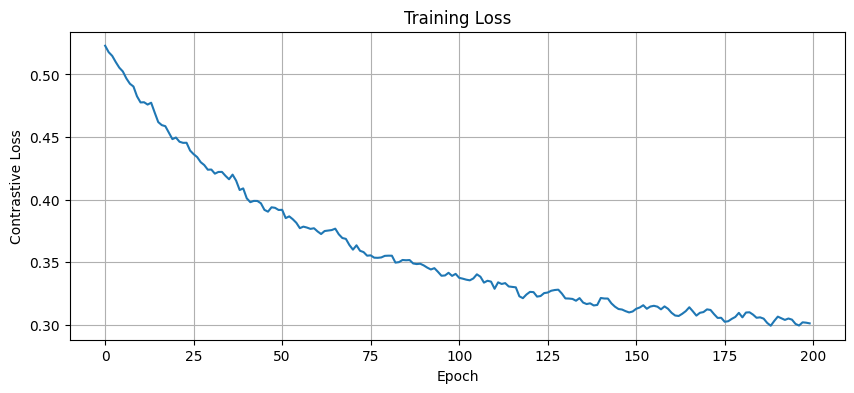

In [13]:
# Plot loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.grid(True)
plt.savefig(str(MODEL_DIR / 'training_loss.png'))
plt.show()

## 6. Evaluate

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings
audio_embs = audio_encoder.predict(X_audio)  # [num_samples, 256]
text_embs = text_projection.predict(X_text_full)  # [num_unique_texts, 256]

print(f"Audio embeddings: {audio_embs.shape}")
print(f"Text embeddings: {text_embs.shape}")

# Similarity: each audio vs all texts
sim_matrix = cosine_similarity(audio_embs, text_embs)  # [num_samples, num_unique_texts]

# Accuracy: does each audio's top match equal its true label?
predictions = np.argmax(sim_matrix, axis=1)
accuracy = np.mean(predictions == X_labels)

# Top-5 accuracy
top5_preds = np.argsort(sim_matrix, axis=1)[:, -5:]
top5_acc = np.mean([X_labels[i] in top5_preds[i] for i in range(len(X_labels))])

print(f"\nTop-1 accuracy: {accuracy*100:.2f}%")
print(f"Top-5 accuracy: {top5_acc*100:.2f}%")
print(f"Mean similarity (correct pairs): {np.mean([sim_matrix[i, X_labels[i]] for i in range(len(X_labels))]):.3f}")
print(f"Mean similarity (wrong pairs): {np.mean(sim_matrix) - np.mean([sim_matrix[i, X_labels[i]] for i in range(len(X_labels))]) / len(unique_texts):.3f}")

56/56 [==============================] - 0s 3ms/step
Audio embeddings: (3360, 256)
Text embeddings: (1792, 256)

Top-1 accuracy: 100.00%
Top-5 accuracy: 100.00%
Mean similarity (correct pairs): 0.986
Mean similarity (wrong pairs): -0.001


## 7. Export for ESP32

In [15]:
# Save audio encoder as TFLite (for ESP32)
print("Converting audio encoder to TFLite...")

converter = tf.lite.TFLiteConverter.from_keras_model(audio_encoder)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.int8]  # Full int8 quantization

# Representative dataset for quantization
def representative_dataset():
    for i in range(min(100, len(X_audio))):
        yield [X_audio[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.inference_input_type = tf.float32  # Keep float input for simplicity
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'audio_encoder.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Saved: {tflite_path}")
print(f"Size: {len(tflite_model) / 1024:.1f} KB")

Converting audio encoder to TFLite...
INFO:tensorflow:Assets written to: /tmp/tmpuoais2mj/assets


INFO:tensorflow:Assets written to: /tmp/tmpuoais2mj/assets
W0000 00:00:1764438144.504441   21906 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764438144.504513   21906 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-29 17:42:24.505896: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpuoais2mj
2025-11-29 17:42:24.507522: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-29 17:42:24.507533: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpuoais2mj
I0000 00:00:1764438144.518307   21906 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-11-29 17:42:24.519349: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-29 17:42:24.546204: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpuoais2mj
2025-11-29 17:42:24.555

Saved: /workspace/models/audio_encoder.tflite
Size: 288.1 KB


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
2025-11-29 17:42:26.162400: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [16]:
# Generate query embeddings (text -> 256-dim)
print("Generating query embeddings...")

# Use unique questions from full.csv if available (may have more questions than audio)
qa_file = DATA_DIR / 'full.csv'
if qa_file.exists():
    import pandas as pd
    qa_df = pd.read_csv(qa_file)
    export_questions = qa_df['question'].tolist()
    print(f"Using {len(export_questions)} questions from full.csv")
else:
    # Use the unique texts from training
    export_questions = unique_texts
    print(f"Using {len(export_questions)} unique questions from training data")

# Encode with sentence transformer and project to 256-dim
export_text_embs_768 = text_encoder.encode(export_questions, show_progress_bar=True)
export_embeddings = text_projection.predict(export_text_embs_768)

print(f"Query embeddings: {export_embeddings.shape}")

Generating query embeddings...
Using 2008 questions from full.csv


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

63/63 [==============================] - 0s 3ms/step
Query embeddings: (2008, 256)


In [17]:
# Save embeddings.bin
embeddings_path = MODEL_DIR / 'embeddings.bin'
with open(embeddings_path, 'wb') as f:
    for emb in export_embeddings:
        f.write(struct.pack(f'{EMBEDDING_DIM}f', *emb))

print(f"Saved: {embeddings_path}")
print(f"  Count: {len(export_embeddings)}")
print(f"  Size: {embeddings_path.stat().st_size / 1024:.1f} KB")

# Save intents.txt
intents_path = MODEL_DIR / 'intents.txt'
with open(intents_path, 'w') as f:
    for q in export_questions:
        f.write(f"{q}\n")

print(f"\nSaved: {intents_path}")
print(f"  Count: {len(export_questions)}")

Saved: /workspace/models/embeddings.bin
  Count: 2008
  Size: 2008.0 KB

Saved: /workspace/models/intents.txt
  Count: 2008


In [18]:
# Summary
print("="*60)
print("TRAINING COMPLETE - FILES FOR ESP32")
print("="*60)

for f in sorted(MODEL_DIR.glob('*')):
    if f.is_file():
        size = f.stat().st_size
        if size > 1024*1024:
            print(f"  {f.name}: {size/1024/1024:.2f} MB")
        else:
            print(f"  {f.name}: {size/1024:.1f} KB")

print(f"\nCopy to SD card:")
print(f"  audio_encoder.tflite -> /models/audio_encoder.tflite")
print(f"  embeddings.bin -> /data/embeddings.bin")
print(f"  intents.txt -> /data/intents.txt")
print(f"\n✅ Ready for ESP32!")

TRAINING COMPLETE - FILES FOR ESP32
  audio_encoder.tflite: 288.1 KB
  audio_projection.h5: 2.56 MB
  audio_projection_quantized.tflite: 663.4 KB
  embeddings.bin: 1.96 MB
  intents.txt: 62.3 KB
  text_projection.h5: 2.05 MB
  text_projection.tflite: 526.2 KB
  training_loss.png: 30.5 KB
  yamnet256_training_loss.png: 45.7 KB

Copy to SD card:
  audio_encoder.tflite -> /models/audio_encoder.tflite
  embeddings.bin -> /data/embeddings.bin
  intents.txt -> /data/intents.txt

✅ Ready for ESP32!
